In [23]:
import os

import scanpy as sc
import celloracle as co
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import style

In [24]:
# plot inline
%matplotlib inline

In [25]:
date = datetime.datetime.now().strftime("%Y%m%d")

In [26]:
style.use('default')
style.use(
    '/lustre/scratch126/cellgen/lotfollahi/kl11/'
    'T_perturb/perturbgen/pp/mpl_style.mplstyle'
)


In [27]:
# mk dir
dir_name = f'/lustre/scratch126/cellgen/lotfollahi/kl11/T_perturb/res/hspc/celloracle'
if not os.path.exists(dir_name):
    os.makedirs(dir_name)

In [28]:
# load preprocessed data
full_data = sc.read_h5ad('/lustre/scratch126/cellgen/lotfollahi/kl11/T_perturb/res/hspc/celloracle/full_data.h5ad')

In [29]:
# # # Random downsampling into 30K cells if the anndata object include more than 30 K cells.
# n_cells_downsample = 15000 
# if full_data.shape[0] > n_cells_downsample:
#     # Let's dowmsample into 30K cells
#     sc.pp.subsample(full_data, n_obs=n_cells_downsample, random_state=123)

In [30]:
print(f"Cell number is :{full_data.shape[0]}")

Cell number is :58584


In [31]:
base_GRN = co.data.load_human_promoter_base_GRN()

Loading prebuilt promoter base-GRN. Version: hg19_gimmemotifsv5_fpr2


In [32]:
base_GRN

,peak_id,gene_short_name,9430076C15RIK,AC002126.6,AC012531.1,AC226150.2,AFP,AHR,AHRR,AIRE,...,ZNF784,ZNF8,ZNF816,ZNF85,ZSCAN10,ZSCAN16,ZSCAN22,ZSCAN26,ZSCAN31,ZSCAN4
0,chr10_100027907_100029007,LOXL4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,chr10_100154964_100156064,MIR1287,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,chr10_100174878_100175978,PYROXD2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,chr10_100191017_100192117,MIR4685,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,chr10_100205078_100206178,LOC101927278,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36998,chrY_9558805_9559905,TTTY21B,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
36999,chrY_9572895_9573995,TTTY2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
37000,chrY_9611828_9612928,TTTY1B,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
37001,chrY_9637762_9638862,TTTY22,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [33]:
# Instantiate Oracle object
oracle = co.Oracle()

In [34]:
Paul_15_data = pd.read_csv("/nfs/team361/am74/Cytomeister/notebooks/HSPC_validation_perturbseq/celloracle/TF_data_in_Paul15.csv")

In [35]:
# Check data in anndata
print("Metadata columns :", list(full_data.obs.columns))
print("Dimensional reduction: ", list(full_data.obsm.keys()))

Metadata columns : ['assignment_id', 'age', 'sex', 'tissue', 'phase', 'S_score', 'G2M_score', 'celltype_v2', 'donor_tissue', 'diff_state', 'dataset', 'n_counts', 'louvain']
Dimensional reduction:  ['X_diffmap', 'X_draw_graph_fa', 'X_pca', 'X_umap']


In [ ]:
full_data.X = full_data.layers["raw_count"].copy()

In [ ]:
# Instantiate Oracle object.
oracle.import_anndata_as_raw_count(adata=full_data,
                                   cluster_column_name="celltype_v2",
                                   embedding_name="X_draw_graph_fa")
oracle.import_TF_data(TF_info_matrix=base_GRN)

5520 genes were found in the adata. Note that Celloracle is intended to use around 1000-3000 genes, so the behavior with this number of genes may differ from what is expected.


In [ ]:
# Make dictionary: dictionary key is TF and dictionary value is list of target genes.
TF_to_TG_dictionary = {}

for TF, TGs in zip(Paul_15_data.TF, Paul_15_data.Target_genes):
    # convert target gene to list
    TG_list = TGs.replace(" ", "").split(",")
    # store target gene list in a dictionary
    TF_to_TG_dictionary[TF] = TG_list

# We invert the dictionary above using a utility function in celloracle.
TG_to_TF_dictionary = co.utility.inverse_dictionary(TF_to_TG_dictionary)
TG_to_TF_dictionary = {
    tg.upper(): [tf.upper() for tf in tfs]
    for tg, tfs in TG_to_TF_dictionary.items()
}

  0%|          | 0/178 [00:00<?, ?it/s]

In [ ]:
oracle.addTFinfo_dictionary(TG_to_TF_dictionary)
# Perform PCA
oracle.perform_PCA()

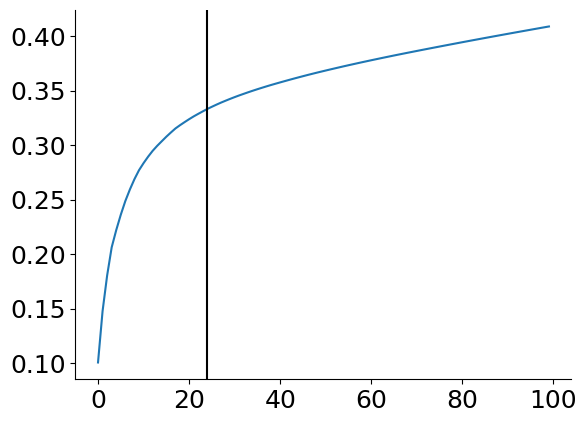

24


In [ ]:
# Select important PCs
plt.plot(np.cumsum(oracle.pca.explained_variance_ratio_)[:100])
n_comps = np.where(np.diff(np.diff(np.cumsum(oracle.pca.explained_variance_ratio_))>0.002))[0][0]
plt.axvline(n_comps, c="k")
plt.show()
print(n_comps)
n_comps = min(n_comps, 50)

In [ ]:
n_cell = oracle.adata.shape[0]
print(f"cell number is :{n_cell}")

cell number is :15000


In [ ]:
k = int(0.025*n_cell)
print(f"Auto-selected k is :{k}")

Auto-selected k is :375


In [ ]:
oracle.knn_imputation(n_pca_dims=n_comps, k=k, balanced=True, b_sight=k*8,
                      b_maxl=k*4, n_jobs=1)

In [ ]:
# Calculate GRN for each population in "louvain_annot" clustering unit.
# This step may take some time.(~30 minutes)
links = oracle.get_links(cluster_name_for_GRN_unit="celltype_v2", alpha=10,
                         verbose_level=10)
links.links_dict.keys()

In [ ]:
links.filter_links(p=0.001, weight="coef_abs", threshold_number=2000)


In [ ]:
links.plot_degree_distributions(plot_model=False,
                                               #save=f"{save_folder}/degree_distribution/",
                                               )
links.get_network_score()

links.merged_score.head()
links.filter_links()
oracle.get_cluster_specific_TFdict_from_Links(links_object=links)
oracle.fit_GRN_for_simulation(alpha=10,
                              use_cluster_specific_TFdict=True)

In [ ]:
oracle.to_hdf5("./HSPC.celloracle.oracle")
links.to_hdf5(file_path="./HSPC.celloracle.links")
oracle.adata.write_h5ad('./HSPC_oracle.h5ad')